### 1. Import library dan memuat data

Library untuk analisis, preprocessing, clustering, evaluasi, dan PCA disiapkan. Dataset dibaca dari folder data pada repository lokal melalui VS Code. Dataset terdiri dari 5.000 baris dan 9 kolom.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)
from sklearn.neighbors import NearestNeighbors
from scipy.cluster.hierarchy import linkage, dendrogram

sns.set_theme(style="whitegrid")

# Cari folder proyek, baik kernel berjalan dari
# folder utama maupun folder notebooks
current_dir = Path.cwd().resolve()
filename = "semiconductor_wafer_defect_dataset.csv"

csv_path = None

for folder in [current_dir, *current_dir.parents]:
    candidate = folder / "data" / filename
    if candidate.is_file():
        csv_path = candidate
        project_root = folder
        break

if csv_path is None:
    raise FileNotFoundError(
        f"File {filename} belum ditemukan di folder data. "
        "Pastikan folder data sejajar dengan folder notebooks."
    )

# Baca dataset
df = pd.read_csv(csv_path)

sensor_cols = [
    "temperature_c",
    "pressure_torr",
    "gas_flow_sccm",
    "etch_rate_nm_min",
    "voltage_v",
    "current_ma"
]

# Periksa kolom yang diperlukan
required_cols = sensor_cols + ["process_step"]
missing_cols = [
    col for col in required_cols
    if col not in df.columns
]

if missing_cols:
    raise ValueError(f"Kolom dataset belum sesuai: {missing_cols}")

print("Lokasi dataset:", csv_path)
print("Ukuran data:", df.shape)
display(df.head())

Lokasi dataset: F:\S1 [ Politeknik Manufaktur Bandung - Teknik Rekayasa Informatika Industri ]\SMT 5\Praktek\MLN\minggu 2\wafer_defect\wafer-defect-classification\data\semiconductor_wafer_defect_dataset.csv
Ukuran data: (5000, 9)


,wafer_id,temperature_c,pressure_torr,gas_flow_sccm,etch_rate_nm_min,voltage_v,current_ma,process_step,defect_label
0,1,457.450712,747.287210,113.215053,93.852614,5.139314,20.341747,Deposition,0
1,2,447.926035,746.397577,116.945005,94.738753,5.113329,20.024511,Lithography,0
2,3,459.715328,706.130705,114.026189,95.514359,4.625392,19.137690,Deposition,0
3,4,472.845448,750.097294,121.104180,102.574892,5.231834,19.994947,Deposition,0
4,5,446.487699,781.984872,131.971785,89.022262,4.403967,20.981683,Deposition,0


### 2. EDA singkat
Periksa tipe data, nilai kosong, duplikat, distribusi kategori proses, dan statistik sensor. `defect_label` boleh diringkas untuk memahami dataset, tetapi tidak dipakai dalam pelatihan.

In [2]:
df.info()
print('Missing value per kolom:')
display(df.isna().sum().to_frame('Jumlah'))
print('Duplikat:', df.duplicated().sum())
display(df.describe(include='all').T)
print('Distribusi process_step:')
display(df['process_step'].value_counts())
print('Distribusi defect_label (hanya informasi tambahan):')
display(df['defect_label'].value_counts())


<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   wafer_id          5000 non-null   int64  
 1   temperature_c     5000 non-null   float64
 2   pressure_torr     5000 non-null   float64
 3   gas_flow_sccm     5000 non-null   float64
 4   etch_rate_nm_min  5000 non-null   float64
 5   voltage_v         5000 non-null   float64
 6   current_ma        5000 non-null   float64
 7   process_step      5000 non-null   str    
 8   defect_label      5000 non-null   int64  
dtypes: float64(6), int64(2), str(1)
memory usage: 390.5 KB
Missing value per kolom:


,Jumlah
wafer_id,0
temperature_c,0
pressure_torr,0
gas_flow_sccm,0
etch_rate_nm_min,0
voltage_v,0
current_ma,0
process_step,0
defect_label,0


Duplikat: 0


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
wafer_id,5000.0,NaN,NaN,NaN,2500.5,1443.520003,1.0,1250.75,2500.5,3750.25,5000.0
temperature_c,5000.0,NaN,NaN,NaN,450.084029,14.947197,401.38099,440.131424,450.201984,459.990159,508.893566
pressure_torr,5000.0,NaN,NaN,NaN,759.703783,30.313113,642.327992,739.402513,759.476484,780.317142,865.871656
gas_flow_sccm,5000.0,NaN,NaN,NaN,120.10553,9.987698,86.244209,113.391136,120.099174,126.755342,154.289105
etch_rate_nm_min,5000.0,NaN,NaN,NaN,95.132121,8.026693,64.148997,89.682554,95.154073,100.652917,130.832674
voltage_v,5000.0,NaN,NaN,NaN,4.992659,0.39335,3.537965,4.719296,4.996793,5.260243,6.44454
current_ma,5000.0,NaN,NaN,NaN,19.986853,1.998921,13.093292,18.601549,19.997914,21.354883,27.383249
process_step,5000,5,CMP,1029,NaN,NaN,NaN,NaN,NaN,NaN,NaN
defect_label,5000.0,NaN,NaN,NaN,0.0014,0.037394,0.0,0.0,0.0,0.0,1.0


Distribusi process_step:


process_step
CMP            1029
Oxidation      1027
Etching         997
Lithography     992
Deposition      955
Name: count, dtype: int64

Distribusi defect_label (hanya informasi tambahan):


defect_label
0    4993
1       7
Name: count, dtype: int64

### 3. Visualisasi EDA
Tiga visualisasi pertama menunjukkan proses manufaktur, distribusi sensor, serta hubungan antar sensor. Perhatikan pola yang dapat membedakan kondisi proses.

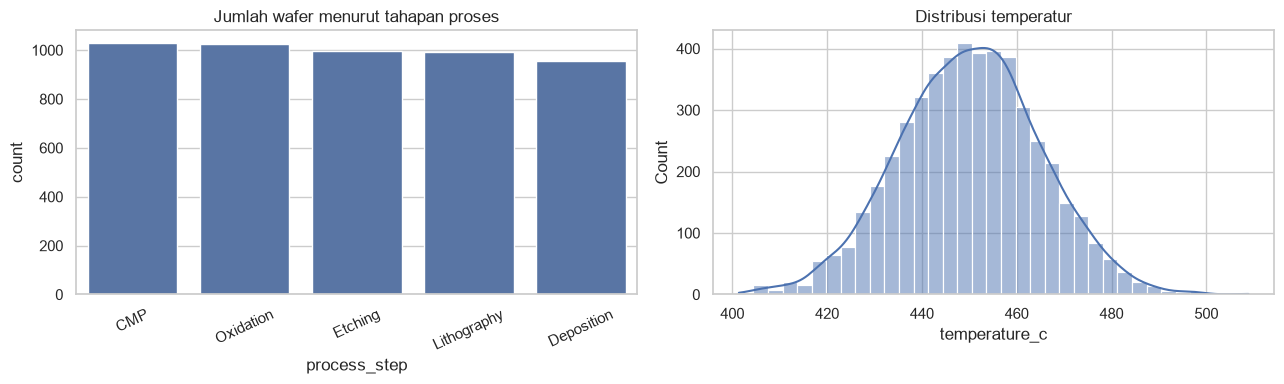

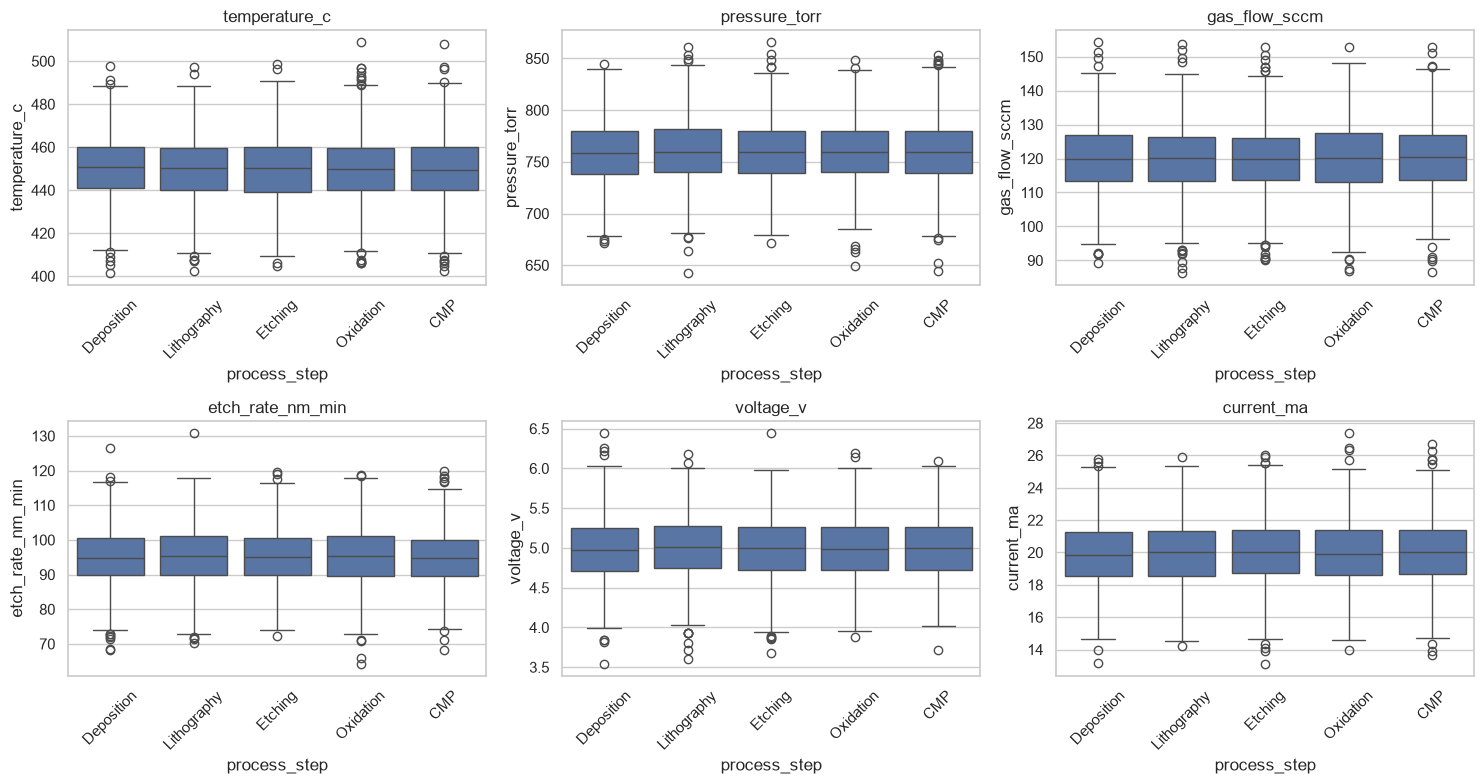

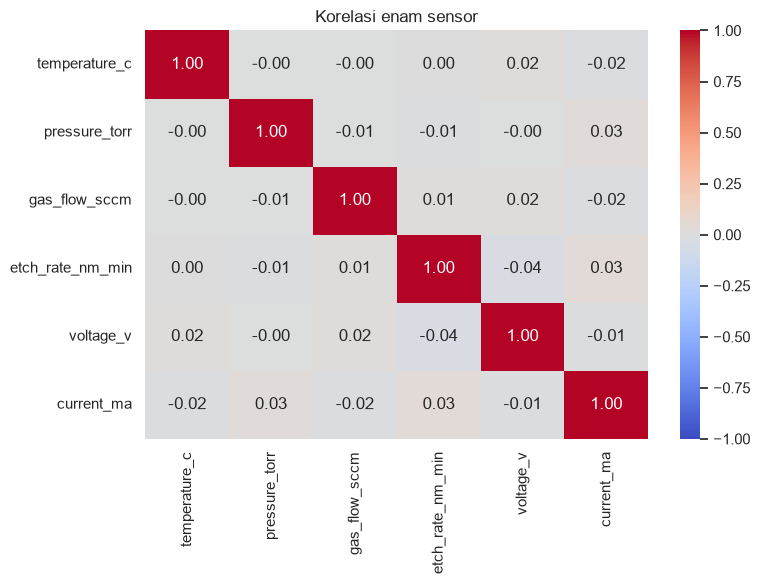

In [3]:
sensor_cols = ['temperature_c', 'pressure_torr', 'gas_flow_sccm',
               'etch_rate_nm_min', 'voltage_v', 'current_ma']
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.countplot(data=df, x='process_step', order=df['process_step'].value_counts().index, ax=axes[0])
axes[0].tick_params(axis='x', rotation=25)
axes[0].set_title('Jumlah wafer menurut tahapan proses')
sns.histplot(data=df, x='temperature_c', bins=35, kde=True, ax=axes[1])
axes[1].set_title('Distribusi temperatur')
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flat, sensor_cols):
    sns.boxplot(data=df, x='process_step', y=col, ax=ax)
    ax.tick_params(axis='x', rotation=45)
    ax.set_title(col)
plt.tight_layout(); plt.show()

plt.figure(figsize=(8, 6))
sns.heatmap(df[sensor_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Korelasi enam sensor'); plt.tight_layout(); plt.show()


### 4. Preprocessing
ID dan label defect dikeluarkan. Nilai kosong numerik diisi dengan median bila ada; kategori diisi modus dan diubah menjadi one-hot. Seluruh fitur kemudian distandardisasi agar jarak antar wafer dapat dibandingkan.

In [4]:
X_raw = df[sensor_cols + ['process_step']].copy()
preprocessor = ColumnTransformer([
    ('sensor', Pipeline([('imputer', SimpleImputer(strategy='median'))]), sensor_cols),
    ('step', Pipeline([('imputer', SimpleImputer(strategy='most_frequent')),
                       ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))]), ['process_step'])
], verbose_feature_names_out=False)
X_prepared = preprocessor.fit_transform(X_raw)
feature_names = preprocessor.get_feature_names_out()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_prepared)
print('Ukuran matriks fitur:', X_scaled.shape)
print('Fitur:', list(feature_names))


Ukuran matriks fitur: (5000, 11)
Fitur: ['temperature_c', 'pressure_torr', 'gas_flow_sccm', 'etch_rate_nm_min', 'voltage_v', 'current_ma', 'process_step_CMP', 'process_step_Deposition', 'process_step_Etching', 'process_step_Lithography', 'process_step_Oxidation']


### 5. Menentukan K untuk K-Means
Elbow menggunakan inertia, sedangkan Silhouette mengukur keterpisahan cluster. Skor dihitung pada sampel tetap agar komputasi tidak terlalu berat. Pilih K berdasarkan keduanya; pilihan awal otomatis menggunakan Silhouette tertinggi.

,K,Inertia,Silhouette
0,2,48708.7660,0.1267
1,3,42434.2139,0.1886
2,4,36198.0943,0.2533
3,5,29982.9635,0.3191
4,6,29214.6519,0.2682
5,7,28476.3161,0.2323
6,8,27762.1174,0.1910


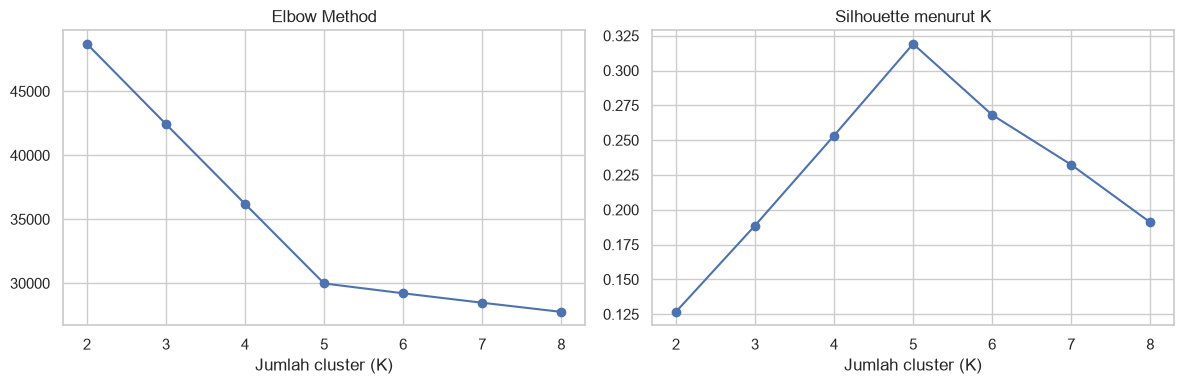

K awal berdasarkan Silhouette: 5


In [5]:
k_values = range(2, 9)
elbow_rows = []
for k in k_values:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = km.fit_predict(X_scaled)
    elbow_rows.append({'K': k, 'Inertia': km.inertia_,
                       'Silhouette': silhouette_score(X_scaled, labels, sample_size=1500, random_state=42)})
elbow_df = pd.DataFrame(elbow_rows)
display(elbow_df.round(4))
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(elbow_df['K'], elbow_df['Inertia'], 'o-'); axes[0].set_title('Elbow Method')
axes[1].plot(elbow_df['K'], elbow_df['Silhouette'], 'o-'); axes[1].set_title('Silhouette menurut K')
for ax in axes: ax.set_xlabel('Jumlah cluster (K)')
plt.tight_layout(); plt.show()
k_optimal = int(elbow_df.loc[elbow_df['Silhouette'].idxmax(), 'K'])
print('K awal berdasarkan Silhouette:', k_optimal)
# Bila titik siku pada grafik menyarankan K lain, ubah k_optimal secara manual dan jelaskan alasannya.


### 6. Persiapan Data untuk Perbandingan Clustering

K-Means, Agglomerative, dan DBSCAN menggunakan hasil preprocessing yang sama dari bagian 4. Kolom wafer_id dan defect_label tidak digunakan sebagai input clustering. Enam sensor dan process_step menghasilkan 11 fitur setelah One-Hot Encoding, kemudian distandardisasi.

In [6]:
# Gunakan hasil dari cell "4. Preprocessing".
# Tidak membaca CSV atau melakukan encoding/scaling ulang.

df_clean = X_raw.copy()

# Kolom sensor untuk analisis profil cluster
clustering_features = sensor_cols.copy()

print("Jumlah data:", X_scaled.shape[0])
print("Jumlah fitur setelah preprocessing:", X_scaled.shape[1])

print("\nFitur yang digunakan:")
print(list(feature_names))

print("\nKategori process_step:")
print(sorted(X_raw["process_step"].dropna().unique()))

Jumlah data: 5000
Jumlah fitur setelah preprocessing: 11

Fitur yang digunakan:
['temperature_c', 'pressure_torr', 'gas_flow_sccm', 'etch_rate_nm_min', 'voltage_v', 'current_ma', 'process_step_CMP', 'process_step_Deposition', 'process_step_Etching', 'process_step_Lithography', 'process_step_Oxidation']

Kategori process_step:
['CMP', 'Deposition', 'Etching', 'Lithography', 'Oxidation']


### 7. Menentukan eps dan min_samples

Beberapa kombinasi `eps` dan `min_samples` diuji untuk mendapatkan hasil clustering yang sesuai.

In [7]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.metrics import davies_bouldin_score
from sklearn.metrics import calinski_harabasz_score

kombinasi = [
    (1.0, 5),
    (1.2, 5),
    (1.4, 3),
    (1.5, 3),
    (1.6, 3),
    (1.7, 3),
    (1.8, 3)
]

hasil_dbscan = []

for eps, min_samples in kombinasi:
    dbscan = DBSCAN(eps=eps, min_samples=min_samples)
    labels = dbscan.fit_predict(X_scaled)

    jumlah_cluster = len(set(labels)) - (1 if -1 in labels else 0)
    jumlah_noise = np.sum(labels == -1)
    noise_percent = (jumlah_noise / len(labels)) * 100

    mask = labels != -1

    if jumlah_cluster >= 2 and mask.sum() > jumlah_cluster:
        silhouette = silhouette_score(X_scaled[mask], labels[mask])
        davies = davies_bouldin_score(X_scaled[mask], labels[mask])
        calinski = calinski_harabasz_score(X_scaled[mask], labels[mask])
    else:
        silhouette = np.nan
        davies = np.nan
        calinski = np.nan

    hasil_dbscan.append({
        'eps': eps,
        'min_samples': min_samples,
        'Jumlah Cluster': jumlah_cluster,
        'Noise (%)': round(noise_percent, 2),
        'Silhouette Score': silhouette,
        'Davies-Bouldin Index': davies,
        'Calinski-Harabasz Index': calinski
    })

hasil_dbscan = pd.DataFrame(hasil_dbscan)

hasil_dbscan.round(4)

,eps,min_samples,Jumlah Cluster,Noise (%),Silhouette Score,Davies-Bouldin Index,Calinski-Harabasz Index
0,1.0,5,27,58.32,-0.0440,1.1930,134.2997
1,1.2,5,9,28.30,0.2049,1.1245,512.2382
2,1.4,3,14,8.98,0.1568,1.0512,336.5308
3,1.5,3,10,5.90,0.2205,1.1108,480.2616
4,1.6,3,7,3.44,0.2911,1.1758,711.9670
5,1.7,3,7,2.34,0.2877,1.1834,710.0955
6,1.8,3,5,1.56,0.3270,1.3281,1055.2378


### 8. Hasil Percobaan

Hasil setiap kombinasi dibandingkan berdasarkan jumlah cluster, noise, dan nilai evaluasi clustering.

In [8]:
# Menampilkan hasil pencarian parameter DBSCAN
# yang sudah dijalankan pada bagian 6.

print("Hasil percobaan parameter DBSCAN:")
display(hasil_dbscan.round(4))

Hasil percobaan parameter DBSCAN:


,eps,min_samples,Jumlah Cluster,Noise (%),Silhouette Score,Davies-Bouldin Index,Calinski-Harabasz Index
0,1.0,5,27,58.32,-0.0440,1.1930,134.2997
1,1.2,5,9,28.30,0.2049,1.1245,512.2382
2,1.4,3,14,8.98,0.1568,1.0512,336.5308
3,1.5,3,10,5.90,0.2205,1.1108,480.2616
4,1.6,3,7,3.44,0.2911,1.1758,711.9670
5,1.7,3,7,2.34,0.2877,1.1834,710.0955
6,1.8,3,5,1.56,0.3270,1.3281,1055.2378


### 9. Training DBSCAN

DBSCAN dijalankan menggunakan parameter yang telah dipilih dari hasil percobaan sebelumnya.

In [9]:
# Pilih kandidat yang memiliki metrik evaluasi valid.
valid_dbscan = hasil_dbscan.dropna(
    subset=["Silhouette Score"]
).copy()

if valid_dbscan.empty:
    raise ValueError(
        "Tidak ada kandidat DBSCAN dengan minimal dua cluster "
        "yang dapat dievaluasi. Perlu mencoba parameter lain."
    )

# Pilihan awal berdasarkan silhouette tertinggi.
# Noise tetap diperiksa pada hasil di bawah.
best_row = valid_dbscan.sort_values(
    ["Silhouette Score", "Noise (%)"],
    ascending=[False, True]
).iloc[0]

best_eps = float(best_row["eps"])
best_min_samples = int(best_row["min_samples"])

dbscan = DBSCAN(
    eps=best_eps,
    min_samples=best_min_samples
)

labels_dbscan = dbscan.fit_predict(X_scaled)

jumlah_cluster = len(set(labels_dbscan) - {-1})
jumlah_noise = int(np.sum(labels_dbscan == -1))
noise_percent = 100 * jumlah_noise / len(labels_dbscan)

print("Parameter DBSCAN terpilih")
print("eps:", best_eps)
print("min_samples:", best_min_samples)
print("Jumlah cluster:", jumlah_cluster)
print("Jumlah noise:", jumlah_noise)
print(f"Persentase noise: {noise_percent:.2f}%")

display(best_row.to_frame("Hasil kandidat terpilih"))

Parameter DBSCAN terpilih
eps: 1.8
min_samples: 3
Jumlah cluster: 5
Jumlah noise: 78
Persentase noise: 1.56%


,Hasil kandidat terpilih
eps,1.800000
min_samples,3.000000
Jumlah Cluster,5.000000
Noise (%),1.560000
Silhouette Score,0.326962
Davies-Bouldin Index,1.328123
Calinski-Harabasz Index,1055.237796


### 10. Visualisasi DBSCAN

Hasil clustering divisualisasikan menggunakan PCA 2 dimensi untuk melihat persebaran cluster dan noise.

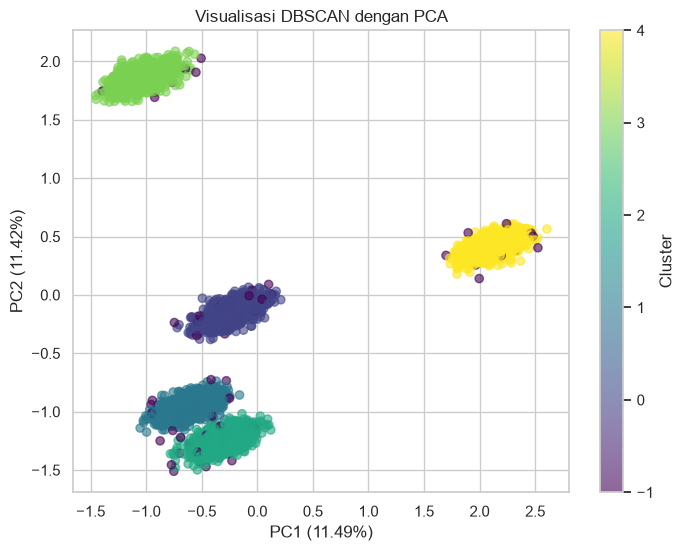

In [10]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))

scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=labels_dbscan,
    cmap='viridis',
    alpha=0.6
)

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0] * 100:.2f}%)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1] * 100:.2f}%)')
plt.title('Visualisasi DBSCAN dengan PCA')
plt.colorbar(scatter, label='Cluster')

plt.show()

### 11. Interpretasi Hasil DBSCAN

Dari kombinasi parameter yang diuji, eps = 1,8 dan min_samples = 3 menghasilkan Silhouette tertinggi, yaitu 0,3270. Model membentuk 5 cluster dan mengidentifikasi 78 wafer sebagai noise atau 1,56% dari seluruh data.

Davies-Bouldin Index sebesar 1,3281 dan Calinski-Harabasz Index sebesar 1055,2378 dihitung pada 4.922 wafer yang bukan noise. Nilai tersebut menunjukkan adanya pola pengelompokan, tetapi tidak membuktikan bahwa cluster atau noise merupakan kondisi mesin rusak.

Label -1 menunjukkan data yang tidak masuk ke kelompok padat menurut parameter DBSCAN. Data tersebut memerlukan pemeriksaan lebih lanjut sebelum dianggap sebagai anomali proses.

### 12. Agglomerative Clustering

Agglomerative Clustering mengelompokkan data secara hierarki dengan menggabungkan cluster yang memiliki jarak terdekat. Jumlah cluster menggunakan `k_optimal` dari tahap K-Means dan metode yang digunakan adalah `Ward linkage`.

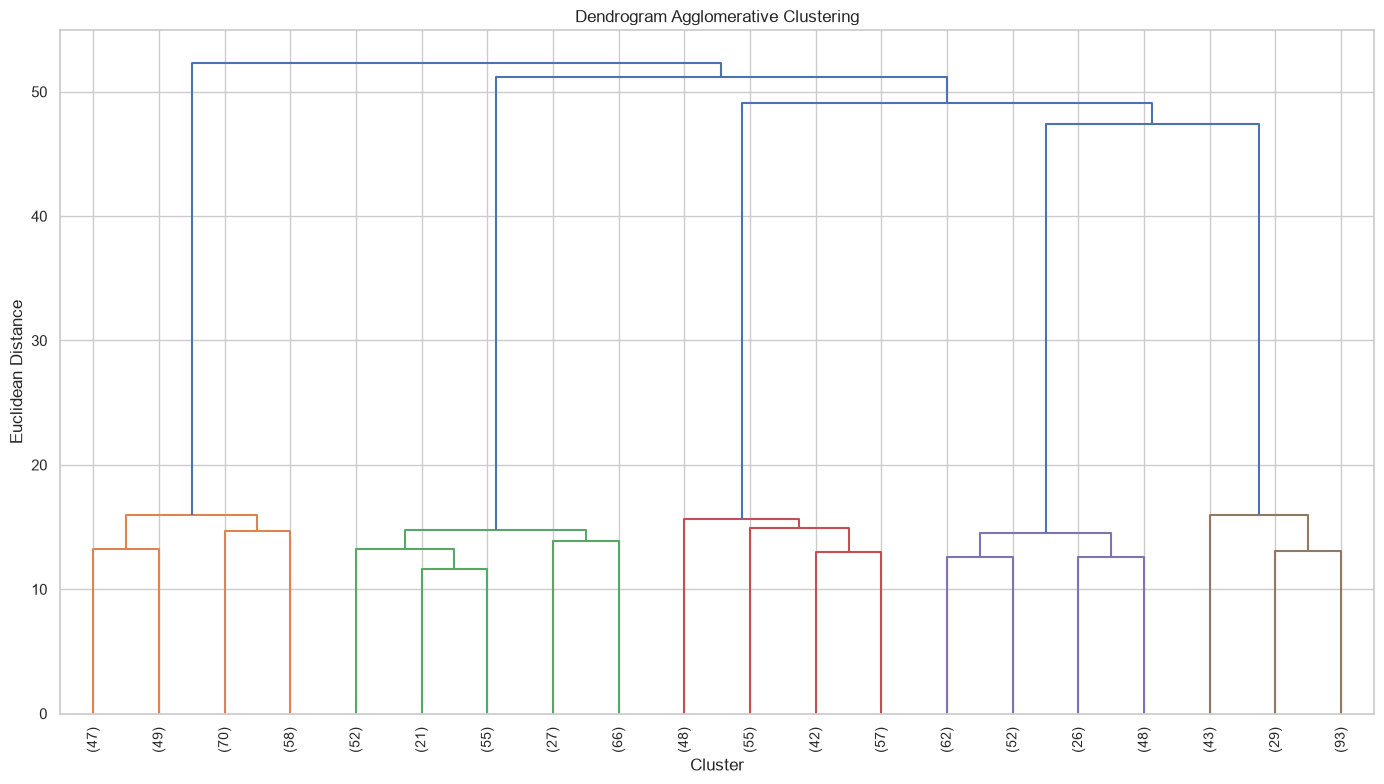

Jumlah Cluster: 5
Distribusi Cluster:
cluster_agg
0    1027
1     992
2     955
3    1029
4     997
Name: count, dtype: int64


In [11]:
# Dendrogram dan training Agglomerative Clustering

sample_size = min(1000, len(X_scaled))
rng = np.random.default_rng(42)
indices = rng.choice(len(X_scaled), sample_size, replace=False)
X_sample = X_scaled[indices]

linked = linkage(X_sample, method='ward')

plt.figure(figsize=(14, 8))
dendrogram(
    linked,
    truncate_mode='lastp',
    p=20,
    leaf_rotation=90,
    leaf_font_size=10
)
plt.title('Dendrogram Agglomerative Clustering')
plt.xlabel('Cluster')
plt.ylabel('Euclidean Distance')
plt.tight_layout()
plt.show()

# Model Agglomerative
agg = AgglomerativeClustering(
    n_clusters=k_optimal,
    linkage='ward'
)

agg_labels = agg.fit_predict(X_scaled)
df_clean['cluster_agg'] = agg_labels

print('Jumlah Cluster:', k_optimal)
print('Distribusi Cluster:')
print(df_clean['cluster_agg'].value_counts().sort_index())

### 13 Evaluasi Agglomerative Clustering

Evaluasi dilakukan menggunakan Silhouette Score, Davies-Bouldin Index, dan Calinski-Harabasz Index untuk mengetahui kualitas hasil clustering.

In [12]:
# Evaluasi Agglomerative Clustering

sil_agg = silhouette_score(X_scaled, agg_labels)
db_agg = davies_bouldin_score(X_scaled, agg_labels)
ch_agg = calinski_harabasz_score(X_scaled, agg_labels)

print(f"Silhouette Score        : {sil_agg:.4f}")
print(f"Davies-Bouldin Index    : {db_agg:.4f}")
print(f"Calinski-Harabasz Index : {ch_agg:.2f}")

Silhouette Score        : 0.3230
Davies-Bouldin Index    : 1.3406
Calinski-Harabasz Index : 1041.93


### 14. Visualisasi Hasil Agglomerative Clustering

Hasil Agglomerative Clustering divisualisasikan menggunakan dua komponen utama PCA untuk melihat persebaran setiap cluster.

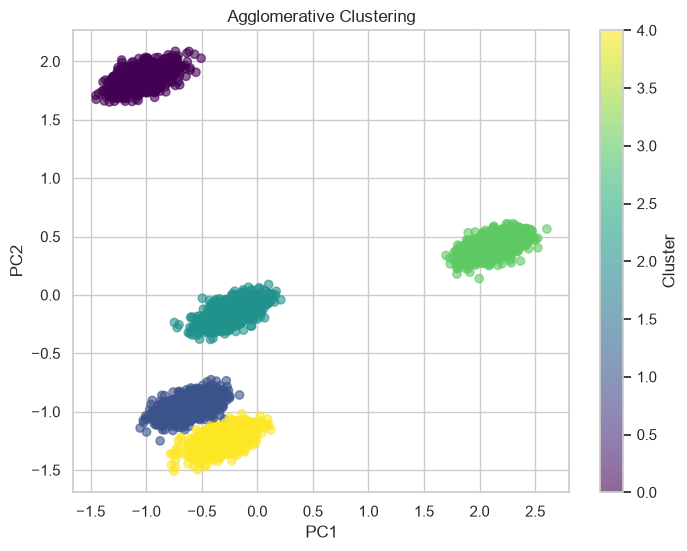

In [13]:
# PCA untuk visualisasi

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=agg_labels,
    cmap='viridis',
    alpha=0.6
)

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Agglomerative Clustering')
plt.colorbar(label='Cluster')

plt.show()

### 15. Profil Cluster Agglomerative

Profil cluster digunakan untuk melihat karakteristik rata-rata setiap cluster berdasarkan fitur yang digunakan dalam proses clustering.

In [14]:
# Profil Cluster

cluster_profile_agg = df_clean.groupby('cluster_agg')[clustering_features].mean()

display(cluster_profile_agg.round(3))

,temperature_c,pressure_torr,gas_flow_sccm,etch_rate_nm_min,voltage_v,current_ma
cluster_agg,,,,,,
0,450.141,759.577,120.127,95.271,4.994,19.983
1,449.979,760.873,120.139,95.494,4.998,19.937
2,450.643,758.441,119.982,95.013,4.983,19.922
3,449.801,759.600,120.365,94.718,5.003,20.051
4,449.886,759.988,119.900,95.170,4.984,20.036


### 16. Perbandingan Algoritma Clustering

Hasil ketiga algoritma clustering dibandingkan menggunakan Silhouette Score, Davies-Bouldin Index, dan Calinski-Harabasz Index.

In [15]:
# Training K-Means menggunakan K hasil pencarian
kmeans = KMeans(
    n_clusters=k_optimal,
    n_init=10,
    random_state=42
)

kmeans_labels = kmeans.fit_predict(X_scaled)


# Evaluasi clustering tanpa memasukkan noise (-1)
def evaluate_clustering(name, X, labels):
    labels = np.asarray(labels)
    mask = labels != -1

    X_valid = X[mask]
    labels_valid = labels[mask]

    n_clusters = len(np.unique(labels_valid))
    n_valid = len(labels_valid)

    result = {
        "Algoritma": name,
        "Jumlah Cluster": n_clusters,
        "Data Dievaluasi": n_valid,
        "Noise (%)": 100 * np.mean(labels == -1),
        "Silhouette Score": np.nan,
        "Davies-Bouldin Index": np.nan,
        "Calinski-Harabasz Index": np.nan
    }

    if 2 <= n_clusters < n_valid:
        result["Silhouette Score"] = silhouette_score(
            X_valid, labels_valid
        )
        result["Davies-Bouldin Index"] = davies_bouldin_score(
            X_valid, labels_valid
        )
        result["Calinski-Harabasz Index"] = calinski_harabasz_score(
            X_valid, labels_valid
        )

    return result


comparison_df = pd.DataFrame([
    evaluate_clustering("K-Means", X_scaled, kmeans_labels),
    evaluate_clustering("Agglomerative", X_scaled, agg_labels),
    evaluate_clustering("DBSCAN", X_scaled, labels_dbscan)
])

print("Perbandingan hasil clustering:")
display(comparison_df.round(4))

print("\nJumlah wafer setiap cluster K-Means:")
display(
    pd.Series(kmeans_labels, name="Cluster")
    .value_counts()
    .sort_index()
    .rename_axis("Cluster")
    .to_frame("Jumlah wafer")
)

print(
    "\nCatatan: evaluasi DBSCAN mengecualikan noise, "
    "sehingga jumlah data yang dievaluasi bisa berbeda."
)

Perbandingan hasil clustering:


,Algoritma,Jumlah Cluster,Data Dievaluasi,Noise (%),Silhouette Score,Davies-Bouldin Index,Calinski-Harabasz Index
0,K-Means,5,5000,0.00,0.323,1.3406,1041.9258
1,Agglomerative,5,5000,0.00,0.323,1.3406,1041.9258
2,DBSCAN,5,4922,1.56,0.327,1.3281,1055.2378



Jumlah wafer setiap cluster K-Means:


,Jumlah wafer
Cluster,
0,992
1,997
2,1029
3,955
4,1027



Catatan: evaluasi DBSCAN mengecualikan noise, sehingga jumlah data yang dievaluasi bisa berbeda.


### 17. Profil Cluster K-Means

Profil cluster menampilkan jumlah wafer, rata-rata enam sensor dalam satuan asli, dan distribusi tahapan proses. Hasil ini digunakan untuk menjelaskan karakteristik setiap kelompok tanpa langsung menganggapnya sebagai kondisi normal atau rusak.

Jumlah wafer dan rata-rata sensor:


,Jumlah wafer,temperature_c,pressure_torr,gas_flow_sccm,etch_rate_nm_min,voltage_v,current_ma
cluster_kmeans,,,,,,,
0,992,449.979,760.873,120.139,95.494,4.998,19.937
1,997,449.886,759.988,119.900,95.170,4.984,20.036
2,1029,449.801,759.600,120.365,94.718,5.003,20.051
3,955,450.643,758.441,119.982,95.013,4.983,19.922
4,1027,450.141,759.577,120.127,95.271,4.994,19.983



Jumlah wafer menurut cluster dan tahapan proses:


process_step,CMP,Deposition,Etching,Lithography,Oxidation
cluster_kmeans,,,,,
0,0,0,0,992,0
1,0,0,997,0,0
2,1029,0,0,0,0
3,0,955,0,0,0
4,0,0,0,0,1027



Persentase tahapan proses setiap cluster:


process_step,CMP,Deposition,Etching,Lithography,Oxidation
cluster_kmeans,,,,,
0,0.0,0.0,0.0,100.0,0.0
1,0.0,0.0,100.0,0.0,0.0
2,100.0,0.0,0.0,0.0,0.0
3,0.0,100.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,100.0


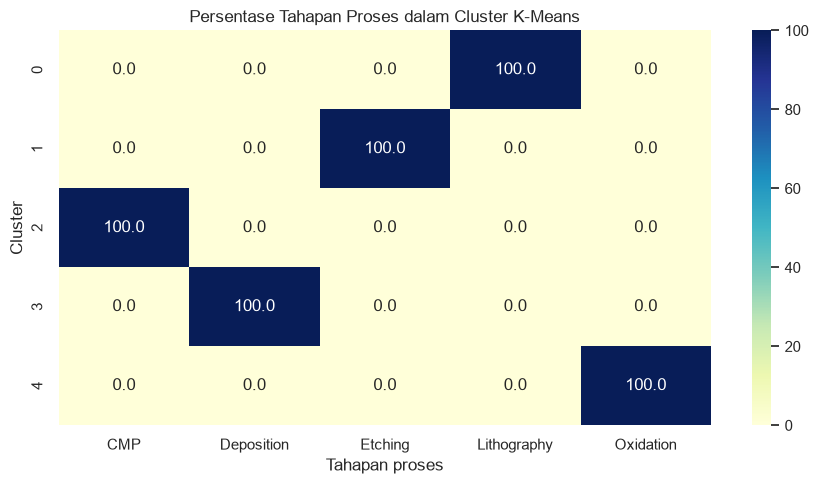

In [16]:
# Data asli untuk menjelaskan karakteristik cluster
df_profile = X_raw.copy()
df_profile["cluster_kmeans"] = kmeans_labels

# Jumlah anggota setiap cluster
cluster_counts = (
    df_profile.groupby("cluster_kmeans")
    .size()
    .rename("Jumlah wafer")
)

# Rata-rata sensor dalam satuan asli
cluster_profile_kmeans = (
    df_profile.groupby("cluster_kmeans")[sensor_cols]
    .mean()
)

print("Jumlah wafer dan rata-rata sensor:")
display(
    cluster_counts.to_frame()
    .join(cluster_profile_kmeans)
    .round(3)
)

# Distribusi tahapan proses setiap cluster
cluster_process_counts = pd.crosstab(
    df_profile["cluster_kmeans"],
    df_profile["process_step"]
)

print("\nJumlah wafer menurut cluster dan tahapan proses:")
display(cluster_process_counts)

# Persentase proses di dalam setiap cluster
cluster_process_percent = (
    cluster_process_counts
    .div(cluster_process_counts.sum(axis=1), axis=0)
    * 100
)

print("\nPersentase tahapan proses setiap cluster:")
display(cluster_process_percent.round(2))

# Grafik untuk melihat keterkaitan cluster dengan proses
plt.figure(figsize=(9, 5))
sns.heatmap(
    cluster_process_percent,
    annot=True,
    fmt=".1f",
    cmap="YlGnBu",
    vmin=0,
    vmax=100
)
plt.title("Persentase Tahapan Proses dalam Cluster K-Means")
plt.xlabel("Tahapan proses")
plt.ylabel("Cluster")
plt.tight_layout()
plt.show()

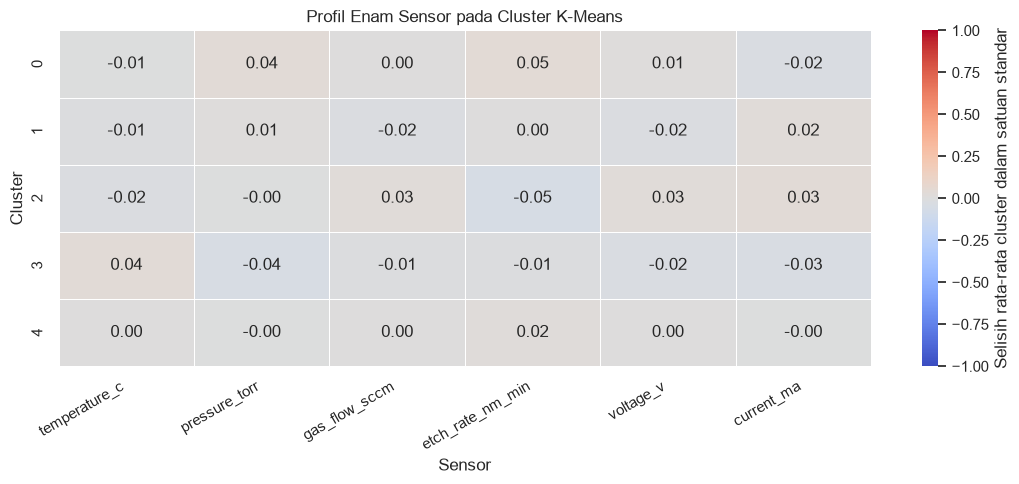

Rata-rata sensor dalam satuan asli:


,temperature_c,pressure_torr,gas_flow_sccm,etch_rate_nm_min,voltage_v,current_ma
cluster_kmeans,,,,,,
0,449.979,760.873,120.139,95.494,4.998,19.937
1,449.886,759.988,119.900,95.170,4.984,20.036
2,449.801,759.600,120.365,94.718,5.003,20.051
3,450.643,758.441,119.982,95.013,4.983,19.922
4,450.141,759.577,120.127,95.271,4.994,19.983


In [17]:
# Rata-rata sensor setiap cluster dalam satuan asli
sensor_means = (
    df_profile.groupby("cluster_kmeans")[sensor_cols]
    .mean()
)

# Bandingkan rata-rata cluster terhadap seluruh dataset.
# Warna memakai satuan standar agar sensor dengan
# skala berbeda dapat dibandingkan.
overall_mean = X_raw[sensor_cols].mean()
overall_std = X_raw[sensor_cols].std(ddof=0).replace(0, np.nan)

sensor_profile_standardized = (
    (sensor_means - overall_mean) / overall_std
).fillna(0)

plt.figure(figsize=(11, 5))

sns.heatmap(
    sensor_profile_standardized,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    cbar_kws={
        "label": "Selisih rata-rata cluster dalam satuan standar"
    }
)

plt.title("Profil Enam Sensor pada Cluster K-Means")
plt.xlabel("Sensor")
plt.ylabel("Cluster")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

print("Rata-rata sensor dalam satuan asli:")
display(sensor_means.round(3))

### Interpretasi Heatmap Profil Sensor

Heatmap membandingkan rata-rata sensor setiap cluster terhadap rata-rata seluruh dataset dalam satuan standar. Nilai positif menunjukkan rata-rata cluster lebih tinggi, sedangkan nilai negatif menunjukkan rata-rata lebih rendah.

Warna menggunakan rentang tetap -1 hingga 1 agar perbedaan kecil tidak terlihat berlebihan. Grafik ini melengkapi profil tahapan proses dan tidak menentukan batas kondisi normal atau rusak.

### 18. Interpretasi Profil Cluster K-Means

K-Means menghasilkan 5 cluster yang seluruh anggotanya mengikuti satu tahapan proses. Cluster 0 berisi 992 wafer Lithography, cluster 1 berisi 997 wafer Etching, cluster 2 berisi 1.029 wafer CMP, cluster 3 berisi 955 wafer Deposition, dan cluster 4 berisi 1.027 wafer Oxidation.

Rata-rata enam sensor antarcluster relatif berdekatan. Kesesuaian cluster dengan process_step sebesar 100% menunjukkan bahwa hasil pengelompokan saat ini terutama mengikuti kategori tahapan produksi. Penyertaan fitur process_step melalui One-Hot Encoding dan standardisasi kemungkinan berkontribusi besar terhadap pemisahan tersebut.

Cluster belum dapat diberi label normal atau rusak. Untuk mempelajari variasi kondisi sensor dalam satu proses, analisis lanjutan dapat dilakukan per tahapan proses atau dengan membandingkan clustering tanpa fitur process_step.

### 19. PCA Analysis dan Visualisasi Cluster

PCA digunakan untuk mengurangi dimensi data sehingga hasil clustering dapat divisualisasikan dalam bentuk 2 dimensi.

Jumlah principal component ditentukan berdasarkan cumulative explained variance dengan target lebih dari 80%.

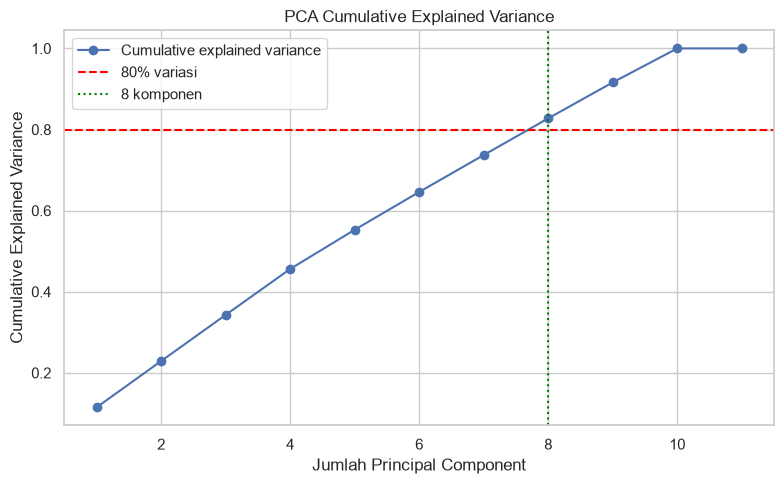

Jumlah komponen untuk mencapai minimal 80%: 8
Variasi yang dipertahankan: 82.75%


In [18]:
# PCA untuk melihat cumulative explained variance
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Akumulasi variasi yang dijelaskan
cumulative_variance = np.cumsum(
    pca.explained_variance_ratio_
)

# Jumlah komponen untuk mempertahankan minimal 80% variasi
n_components_80 = int(
    np.searchsorted(cumulative_variance, 0.80) + 1
)

# Grafik cumulative explained variance
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance,
    marker="o",
    label="Cumulative explained variance"
)

plt.axhline(
    y=0.80,
    color="red",
    linestyle="--",
    label="80% variasi"
)

plt.axvline(
    x=n_components_80,
    color="green",
    linestyle=":",
    label=f"{n_components_80} komponen"
)

plt.xlabel("Jumlah Principal Component")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Cumulative Explained Variance")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print(
    "Jumlah komponen untuk mencapai minimal 80%:",
    n_components_80
)
print(
    "Variasi yang dipertahankan:",
    f"{cumulative_variance[n_components_80 - 1] * 100:.2f}%"
)

### 20. Interpretasi PCA Cumulative Explained Variance

Grafik menunjukkan akumulasi variasi data yang dijelaskan oleh komponen utama. Jumlah komponen untuk mempertahankan minimal 80% variasi ditentukan pada titik pertama ketika cumulative explained variance mencapai 0,80.

PCA digunakan untuk visualisasi dan analisis variasi. Training clustering tetap menggunakan seluruh 11 fitur hasil preprocessing.

In [19]:
# PCA 2 Dimensi untuk visualisasi cluster

pca_2d = PCA(n_components=2)

X_pca_2d = pca_2d.fit_transform(X_scaled)

print("Explained variance PC1:",
      pca_2d.explained_variance_ratio_[0])

print("Explained variance PC2:",
      pca_2d.explained_variance_ratio_[1])

print("Total variance 2 PC:",
      sum(pca_2d.explained_variance_ratio_)*100, "%")

Explained variance PC1: 0.1149113897253377
Explained variance PC2: 0.11415665560446174
Total variance 2 PC: 22.906804532979944 %


### 21. Interpretasi PCA 2 Dimensi

PC1 menjelaskan sekitar 11,49% variasi data dan PC2 sekitar 11,42%. Secara keseluruhan, kedua komponen mempertahankan 22,91% variasi data.

Karena sebagian besar variasi tidak ditampilkan, grafik PCA 2D hanya memberikan gambaran sebagian pola cluster. Titik yang bertumpuk pada grafik tidak selalu berarti kelompoknya tidak terpisah pada ruang 11 fitur.

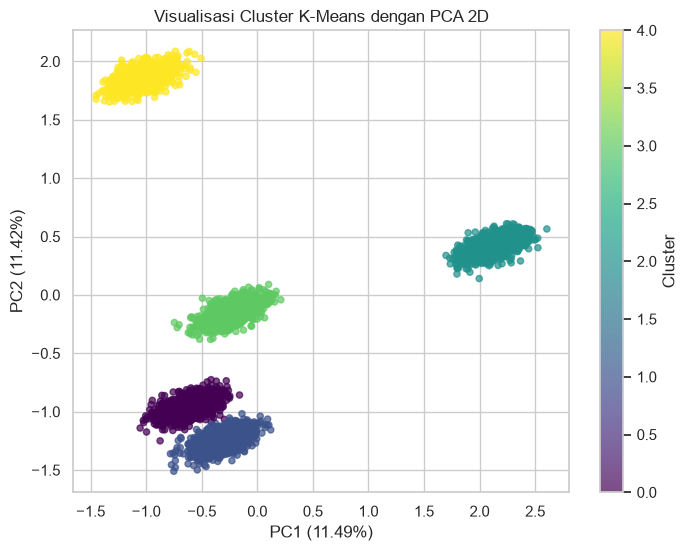

In [20]:
# Visualisasi PCA 2D untuk K-Means

plt.figure(figsize=(8,6))

scatter = plt.scatter(
    X_pca_2d[:, 0],
    X_pca_2d[:, 1],
    c=kmeans_labels,
    cmap='viridis',
    s=20,
    alpha=0.7
)

plt.xlabel(f"PC1 ({pca_2d.explained_variance_ratio_[0]*100:.2f}%)")
plt.ylabel(f"PC2 ({pca_2d.explained_variance_ratio_[1]*100:.2f}%)")
plt.title("Visualisasi Cluster K-Means dengan PCA 2D")

plt.colorbar(scatter, label='Cluster')
plt.grid(True)
plt.show()

### 22. Interpretasi Visualisasi K-Means dengan PCA 2D

K-Means membentuk 5 cluster. Berdasarkan profil cluster, setiap kelompok sesuai dengan satu tahapan proses produksi.

Grafik PCA menampilkan proyeksi hasil clustering ke dua dimensi yang mempertahankan 22,91% variasi data. Interpretasi kelompok perlu mengacu pada profil sensor dan distribusi process_step, bukan hanya posisi titik pada grafik.

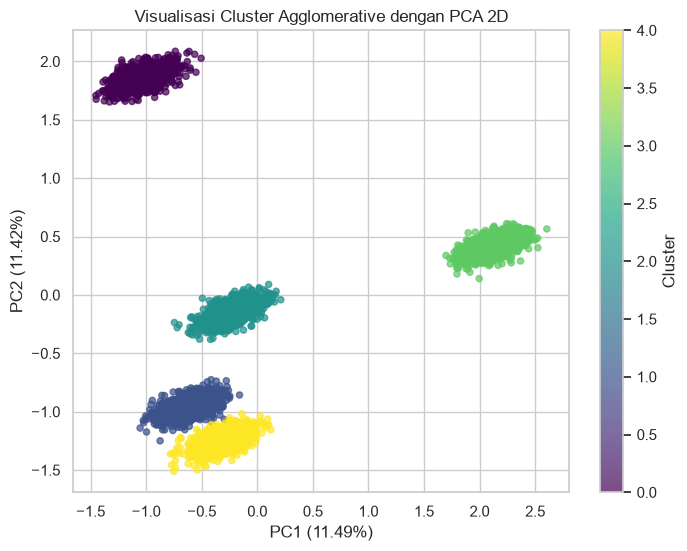

In [21]:
# Visualisasi PCA 2D untuk Agglomerative

plt.figure(figsize=(8,6))

scatter = plt.scatter(
    X_pca_2d[:, 0],
    X_pca_2d[:, 1],
    c=agg_labels,
    cmap='viridis',
    s=20,
    alpha=0.7
)

plt.xlabel(f"PC1 ({pca_2d.explained_variance_ratio_[0]*100:.2f}%)")
plt.ylabel(f"PC2 ({pca_2d.explained_variance_ratio_[1]*100:.2f}%)")
plt.title("Visualisasi Cluster Agglomerative dengan PCA 2D")

plt.colorbar(scatter, label='Cluster')
plt.grid(True)
plt.show()

### 23. Interpretasi Visualisasi Agglomerative dengan PCA 2D

Agglomerative membentuk 5 cluster menggunakan Ward linkage. Metrik evaluasinya sama dengan K-Means hingga ketelitian angka yang ditampilkan.

Proyeksi PCA hanya mempertahankan 22,91% variasi data. Kesamaan metrik belum cukup untuk membuktikan kesamaan seluruh anggota cluster; nomor cluster antaralgoritma juga tidak harus memiliki arti yang sama.

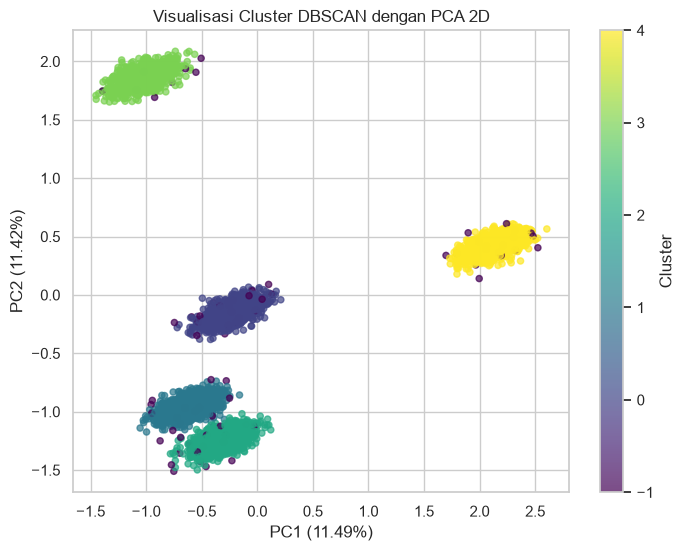

In [22]:
# Visualisasi PCA 2D untuk DBSCAN

plt.figure(figsize=(8,6))

scatter = plt.scatter(
    X_pca_2d[:, 0],
    X_pca_2d[:, 1],
    c=labels_dbscan,
    cmap='viridis',
    s=20,
    alpha=0.7
)

plt.xlabel(f"PC1 ({pca_2d.explained_variance_ratio_[0]*100:.2f}%)")
plt.ylabel(f"PC2 ({pca_2d.explained_variance_ratio_[1]*100:.2f}%)")
plt.title("Visualisasi Cluster DBSCAN dengan PCA 2D")

plt.colorbar(scatter, label='Cluster')
plt.grid(True)
plt.show()

### 24. Interpretasi Visualisasi DBSCAN dengan PCA 2D

DBSCAN membentuk 5 cluster dan menghasilkan 78 titik noise dengan label -1. Grafik menunjukkan proyeksi cluster dan noise pada dua komponen utama.

Penentuan noise dilakukan pada ruang fitur hasil preprocessing, bukan berdasarkan jarak yang terlihat pada grafik PCA. Noise tidak otomatis menunjukkan wafer cacat atau kerusakan mesin.

### 25. Analisis dan Rekomendasi

#### A. Analisis Perbandingan Hasil Clustering

K-Means dan Agglomerative masing-masing menghasilkan 5 cluster dengan Silhouette Score 0,3230, Davies-Bouldin Index 1,3406, dan Calinski-Harabasz Index 1041,9258.

DBSCAN menghasilkan 5 cluster dengan Silhouette Score 0,3270, Davies-Bouldin Index 1,3281, dan Calinski-Harabasz Index 1055,2378. Sebanyak 78 wafer atau 1,56% data merupakan noise dan dikeluarkan dari evaluasi. Oleh karena itu, perbandingan metrik perlu memperhatikan perbedaan cakupan data.

K-Means dipilih untuk modul aplikasi karena dapat memberikan cluster pada input baru melalui predict(). Agglomerative dan DBSCAN tetap digunakan sebagai pembanding analisis.

Profil K-Means menunjukkan bahwa cluster mengikuti tahapan proses secara penuh. Dengan demikian, hasil model saat ini lebih tepat dijelaskan sebagai pengelompokan pola proses produksi, bukan diagnosis kerusakan mesin.

#### B. Rekomendasi untuk Monitoring Kondisi Mesin

Hasil clustering dapat digunakan untuk merangkum kelompok proses produksi dan menampilkan karakteristik sensor tiap kelompok. Pada model saat ini, cluster mengikuti process_step sehingga perubahan cluster dapat mencerminkan perubahan tahapan produksi.

Pemantauan penyimpangan sensor sebaiknya dilakukan terhadap acuan pada tahapan proses yang sama. Penetapan batas normal dan abnormal membutuhkan validasi ahli proses serta informasi tambahan.

#### C. Pengembangan untuk Predictive Maintenance

Model saat ini belum dapat menentukan kebutuhan perawatan mesin. Pengembangan predictive maintenance memerlukan informasi seperti identitas mesin, waktu pengukuran, riwayat perawatan, dan kejadian kerusakan.

Clustering sensor per tahapan proses dapat menjadi analisis awal, tetapi rekomendasi perawatan harus divalidasi menggunakan bukti kondisi mesin.

#### D. Keterbatasan Analisis

1. Dataset memiliki defect_label, tetapi label tersebut tidak digunakan dalam training clustering dan tidak merupakan label kondisi mesin.
2. Profil K-Means menunjukkan kesesuaian 100% antara cluster dan tahapan proses. Model belum menunjukkan pengelompokan kondisi sensor yang independen dari process_step.
3. Hasil bergantung pada pemilihan fitur, encoding, scaling, dan parameter algoritma.
4. Evaluasi DBSCAN mengecualikan noise sehingga cakupan datanya berbeda dari K-Means dan Agglomerative.
5. PCA 2D hanya mempertahankan 22,91% variasi data.
6. Hasil cluster dan noise memerlukan validasi tambahan sebelum digunakan untuk menyimpulkan cacat atau kerusakan.

### Ekspor Model untuk Backend

Preprocessing, standardisasi, dan K-Means disimpan dalam satu pipeline yang sudah dilatih. Backend menerima enam nilai sensor dan process_step dalam satuan asli, kemudian pipeline mengembalikan nomor cluster.

Profil cluster dan metadata disimpan sebagai informasi pendukung. Model ini mengelompokkan pola proses dan tidak memberikan diagnosis wafer cacat atau kerusakan mesin.

In [23]:
import json
import platform
import joblib
import sklearn

# Folder khusus artefak unsupervised
export_dir = project_root / "models" / "unsupervised"
export_dir.mkdir(parents=True, exist_ok=True)

input_features = sensor_cols + ["process_step"]

# Gabungkan komponen yang SUDAH dilatih.
# Tidak melakukan fit ulang.
inference_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("scaler", scaler),
    ("kmeans", kmeans)
])

# Pastikan pipeline menghasilkan cluster yang sama
pipeline_labels = inference_pipeline.predict(
    X_raw[input_features]
)

np.testing.assert_array_equal(
    pipeline_labels,
    kmeans_labels
)

# Metadata dan profil untuk backend
process_categories = (
    preprocessor.named_transformers_["step"]
    .named_steps["onehot"]
    .categories_[0]
    .tolist()
)

profile_data = X_raw[input_features].copy()
profile_data["cluster"] = kmeans_labels

profile_table = (
    profile_data.groupby("cluster")[sensor_cols]
    .mean()
)

profile_table["jumlah_wafer"] = (
    profile_data.groupby("cluster").size()
)

process_counts = pd.crosstab(
    profile_data["cluster"],
    profile_data["process_step"]
)

cluster_profiles = {}

for cluster_id, row in profile_table.iterrows():
    counts = process_counts.loc[cluster_id]
    dominant_process = str(counts.idxmax())

    cluster_profiles[str(int(cluster_id))] = {
        "jumlah_wafer": int(row["jumlah_wafer"]),
        "rata_rata_sensor": {
            col: float(row[col])
            for col in sensor_cols
        },
        "proses_dominan": dominant_process,
        "persentase_proses_dominan": float(
            100 * counts.max() / counts.sum()
        )
    }

metadata = {
    "algorithm": "KMeans",
    "n_clusters": int(kmeans.n_clusters),
    "input_features": input_features,
    "numeric_features": sensor_cols,
    "categorical_features": ["process_step"],
    "process_step_categories": process_categories,
    "transformed_features": list(feature_names),
    "versions": {
        "python": platform.python_version(),
        "scikit_learn": sklearn.__version__,
        "numpy": np.__version__,
        "pandas": pd.__version__,
        "joblib": joblib.__version__
    },
    "interpretation": (
        "Cluster terutama mengikuti tahapan proses. "
        "Nomor cluster bukan label normal/rusak."
    )
}

# Simpan pipeline
model_path = export_dir / "kmeans_pipeline.pkl"
joblib.dump(inference_pipeline, model_path)

# Simpan metadata dan profil
with open(
    export_dir / "metadata.json", "w", encoding="utf-8"
) as file:
    json.dump(metadata, file, indent=2, ensure_ascii=False)

with open(
    export_dir / "cluster_profiles.json", "w", encoding="utf-8"
) as file:
    json.dump(
        cluster_profiles, file,
        indent=2, ensure_ascii=False
    )

comparison_df.to_csv(
    export_dir / "clustering_metrics.csv",
    index=False
)

# Uji baca ulang model dari file
loaded_pipeline = joblib.load(model_path)

test_input = X_raw[input_features].head(5).copy()
expected_labels = inference_pipeline.predict(test_input)
loaded_labels = loaded_pipeline.predict(test_input)

np.testing.assert_array_equal(
    expected_labels,
    loaded_labels
)

# Contoh input/output untuk teman backend
example_input = {
    col: float(test_input.iloc[0][col])
    for col in sensor_cols
}
example_input["process_step"] = str(
    test_input.iloc[0]["process_step"]
)

example_cluster = int(loaded_labels[0])

example_payload = {
    "input": example_input,
    "output": {
        "cluster": example_cluster,
        "profile": cluster_profiles[str(example_cluster)]
    }
}

with open(
    export_dir / "example_prediction.json",
    "w",
    encoding="utf-8"
) as file:
    json.dump(
        example_payload, file,
        indent=2, ensure_ascii=False
    )

print("Ekspor berhasil:", export_dir)
print("Uji pipeline terhadap hasil training: LULUS")
print("Uji prediksi setelah model dimuat ulang: LULUS")

print("\nContoh input/output:")
print(json.dumps(
    example_payload,
    indent=2,
    ensure_ascii=False
))

print("\nFile yang dihasilkan:")
for path in sorted(export_dir.iterdir()):
    print("-", path.name)

Ekspor berhasil: F:\S1 [ Politeknik Manufaktur Bandung - Teknik Rekayasa Informatika Industri ]\SMT 5\Praktek\MLN\minggu 2\wafer_defect\wafer-defect-classification\models\unsupervised
Uji pipeline terhadap hasil training: LULUS
Uji prediksi setelah model dimuat ulang: LULUS

Contoh input/output:
{
  "input": {
    "temperature_c": 457.4507122951685,
    "pressure_torr": 747.287209539319,
    "gas_flow_sccm": 113.21505269512778,
    "etch_rate_nm_min": 93.85261426832857,
    "voltage_v": 5.139314499066727,
    "current_ma": 20.341747057493965,
    "process_step": "Deposition"
  },
  "output": {
    "cluster": 3,
    "profile": {
      "jumlah_wafer": 955,
      "rata_rata_sensor": {
        "temperature_c": 450.6425989152285,
        "pressure_torr": 758.4406730459327,
        "gas_flow_sccm": 119.98247075029109,
        "etch_rate_nm_min": 95.01258752268902,
        "voltage_v": 4.983437878773393,
        "current_ma": 19.921932740072975
      },
      "proses_dominan": "Deposition",
 

### Prediksi Multiple Samples

Pipeline yang telah diekspor digunakan untuk memprediksi beberapa sampel sekaligus. Input berupa enam nilai sensor dan process_step. Hasil ditampilkan dalam tabel berisi nomor cluster dan tahapan proses dominan cluster tersebut.

Contoh ini menggunakan input manual. Backend dapat memakai alur yang sama untuk menerima beberapa sampel dari aplikasi.

In [24]:
# Beberapa contoh input manual dalam satuan asli.
# Nilai ini untuk demonstrasi, bukan batas kondisi normal.
multiple_samples = pd.DataFrame([
    {
        "temperature_c": 450.0,
        "pressure_torr": 760.0,
        "gas_flow_sccm": 120.0,
        "etch_rate_nm_min": 95.0,
        "voltage_v": 5.0,
        "current_ma": 20.0,
        "process_step": "Deposition"
    },
    {
        "temperature_c": 465.0,
        "pressure_torr": 745.0,
        "gas_flow_sccm": 125.0,
        "etch_rate_nm_min": 98.0,
        "voltage_v": 5.1,
        "current_ma": 21.0,
        "process_step": "Deposition"
    },
    {
        "temperature_c": 450.0,
        "pressure_torr": 760.0,
        "gas_flow_sccm": 120.0,
        "etch_rate_nm_min": 95.0,
        "voltage_v": 5.0,
        "current_ma": 20.0,
        "process_step": "Etching"
    }
])

# Validasi input
missing_features = [
    col for col in input_features
    if col not in multiple_samples.columns
]

if missing_features:
    raise ValueError(f"Input belum lengkap: {missing_features}")

for col in sensor_cols:
    multiple_samples[col] = pd.to_numeric(
        multiple_samples[col],
        errors="raise"
    )

if not np.isfinite(
    multiple_samples[sensor_cols].to_numpy(dtype=float)
).all():
    raise ValueError("Semua nilai sensor harus berupa angka finite.")

invalid_categories = (
    set(multiple_samples["process_step"])
    - set(process_categories)
)

if invalid_categories:
    raise ValueError(
        f"Kategori process_step tidak dikenal: {invalid_categories}"
    )

# Prediksi menggunakan model yang dimuat dari file
batch_input = multiple_samples[input_features].copy()
batch_labels = loaded_pipeline.predict(batch_input)

batch_results = batch_input.copy()
batch_results.insert(
    0, "sample_id", range(1, len(batch_results) + 1)
)
batch_results["cluster"] = batch_labels.astype(int)

batch_results["proses_dominan_cluster"] = [
    cluster_profiles[str(int(label))]["proses_dominan"]
    for label in batch_labels
]

# Jarak ke pusat cluster pada ruang fitur standar.
# Bukan probabilitas, confidence, atau indikator kerusakan.
distances = loaded_pipeline.transform(batch_input)
batch_results["jarak_ke_pusat_cluster"] = distances[
    np.arange(len(batch_labels)),
    batch_labels
]

print("Perbandingan prediksi beberapa sampel:")
display(batch_results.round(4))

# Simpan contoh input dan hasil untuk backend
batch_input.to_csv(
    export_dir / "multiple_samples_input.csv",
    index=False
)
batch_results.to_csv(
    export_dir / "multiple_samples_results.csv",
    index=False
)

print("\nFile contoh input dan hasil berhasil disimpan.")
print(
    "Jarak ke pusat cluster bukan diagnosis kondisi mesin."
)

Perbandingan prediksi beberapa sampel:


,sample_id,temperature_c,pressure_torr,gas_flow_sccm,etch_rate_nm_min,voltage_v,current_ma,process_step,cluster,proses_dominan_cluster,jarak_ke_pusat_cluster
0,1,450.0,760.0,120.0,95.0,5.0,20.0,Deposition,3,Deposition,0.0883
1,2,465.0,745.0,125.0,98.0,5.1,21.0,Deposition,3,Deposition,1.3745
2,3,450.0,760.0,120.0,95.0,5.0,20.0,Etching,1,Etching,0.0516



File contoh input dan hasil berhasil disimpan.
Jarak ke pusat cluster bukan diagnosis kondisi mesin.


### Interpretasi Prediksi Multiple Samples

Sampel 1 dan 2 sama-sama masuk cluster 3 yang didominasi proses Deposition. Perubahan sensor pada sampel 2 meningkatkan jarak ke pusat cluster dari 0,0883 menjadi 1,3745, tetapi tidak mengubah kelompoknya.

Sampel 3 memiliki nilai sensor sama dengan sampel 1, tetapi process_step berupa Etching dan masuk cluster 1. Hasil ini memperlihatkan pengaruh tahapan proses terhadap pengelompokan pada contoh yang diuji.

Jarak ke pusat cluster dihitung pada fitur yang sudah ditransformasi dan distandardisasi. Nilai tersebut bukan probabilitas maupun diagnosis kerusakan.